# KardioSense AI — Notebook 1: PTB-XL Baseline ECG Model

**Goal:** To load PTB-XL directly from PhysioNet → preprocess ECG signals → train a baseline ResNet-1D classifier → evaluate on MI + AFib detection.

**Pipeline:**
```
PTB-XL (PhysioNet API) → wfdb load → bandpass filter → normalize
→ ResNet-1D (single-lead baseline) → AUC per condition
```

**Target metrics (end of this notebook):**
- MI AUC ≥ 0.85
- AFib AUC ≥ 0.88
- Inference time < 50ms per sample

**Estimated runtime:** ~45 min on free T4 GPU

---
**Notebook series:**
- `01` — PTB-XL Baseline (this notebook)
- `02` — Lead-Agnostic Masking + Full 6-lead Model 
- `03` — Clinical Branch (XGBoost CVD Risk)
- `04` — Fusion Architecture + Joint Training
- `05` — TFLite Export + On-Device Optimization

## 0. Setup & Google Drive Mount



In [ ]:
# ── Mount Google Drive ─────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os

# ── Project directory structure on Drive ──────────────────────────────
BASE_DIR = os.environ.get('KARDIOSENSE_BASE_DIR', '/content/drive/MyDrive/KardioSenseAI')
DATA_DIR = f'{BASE_DIR}/datasets'
PTBXL_DIR = f'{DATA_DIR}/ptb-xl'
CKPT_DIR = f'{BASE_DIR}/checkpoints'
LOG_DIR = f'{BASE_DIR}/logs'
EXPORT_DIR = f'{BASE_DIR}/exports'

for d in [DATA_DIR, PTBXL_DIR, CKPT_DIR, LOG_DIR, EXPORT_DIR]:
    os.makedirs(d, exist_ok=True)

print('Directory structure ready:')
for d in [BASE_DIR, DATA_DIR, PTBXL_DIR, CKPT_DIR]:
    print(f' {d}')

Mounted at /content/drive
Directory structure ready:
   /content/drive/MyDrive/KardioSenseAI
   /content/drive/MyDrive/KardioSenseAI/datasets
   /content/drive/MyDrive/KardioSenseAI/datasets/ptb-xl
   /content/drive/MyDrive/KardioSenseAI/checkpoints


In [ ]:
# ── Install dependencies ───────────────────────────────────────────────────
# wfdb : reads PhysioNet WFDB-format ECG files
# neurokit2 : ECG signal quality + preprocessing utilities
# imbalanced-learn : for handling class imbalance in rare arrhythmias

!pip install -q wfdb neurokit2 imbalanced-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import signal as scipy_signal
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import wfdb
import ast
import json
import time
import warnings
warnings.filterwarnings('ignore')

# ── Reproducibility ────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'\n Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f' GPU: {torch.cuda.get_device_name(0)}')
    print(f' VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print(' No GPU detected — training will be slow.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 123.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.

 Device: cuda
   GPU: Tesla T4
   VRAM: 15.6 GB


## 1. Download PTB-XL from PhysioNet

PTB-XL is a 12-lead ECG dataset with **21,837 records** and **71 diagnostic labels** organised into 5 superclasses:
- `NORM` — Normal sinus rhythm 
- `MI` — Myocardial Infarction (**our primary target now**)
- `STTC` — ST/T-change (ischemia, LVH)
- `CD` — Conduction disturbance (BBB, AV blocks)
- `HYP` — Hypertrophy

Sampling rates: 100Hz and 500Hz versions available. We are using 500Hz for higher fidelity.

The download checks if data already exists on Drive — so re-running this after the first time is instant.

In [ ]:
# ── Download PTB-XL (skips if already on Drive) ────────────────────────────
# Dataset: https://physionet.org/content/ptb-xl/1.0.3/
# Size: ~1.7 GB (500Hz version)

PTBXL_RECORD_FILE = f'{PTBXL_DIR}/ptbxl_database.csv'

if os.path.exists(PTBXL_RECORD_FILE):
    print('PTB-XL already downloaded on Drive — skipping download.')
else:
    print('Downloading PTB-XL from PhysioNet...')
    !wget -r -N -c -np --no-check-certificate \
        -P {DATA_DIR} \
        https://physionet.org/files/ptb-xl/1.0.3/
    # Rename to cleaner path
    !mv {DATA_DIR}/physionet.org/files/ptb-xl/1.0.3/* {PTBXL_DIR}/
    !rm -rf {DATA_DIR}/physionet.org
    print('Download complete.')

# ── Load the metadata CSV ──────────────────────────────────────────────────
df = pd.read_csv(PTBXL_RECORD_FILE, index_col='ecg_id')
df.scp_codes = df.scp_codes.apply(ast.literal_eval) # parse string → dict

print(f'\n PTB-XL metadata loaded:')
print(f' Records : {len(df):,}')
print(f' Columns : {list(df.columns)[:8]}...')
print(f'\nSample row:')
display(df.head(2))

PTB-XL already downloaded on Drive — skipping download.

 PTB-XL metadata loaded:
   Records : 21,799
   Columns : ['patient_id', 'age', 'sex', 'height', 'weight', 'nurse', 'site', 'device']...

Sample row:


,patient_id,age,sex,height,weight,nurse,site,device,recording_date,report,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
ecg_id,,,,,,,,,,,,,,,,,,,,,
1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,sinusrhythmus periphere niederspannung,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,sinusbradykardie sonst normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr


## 2. Label Engineering

PTB-XL uses SCP-ECG diagnostic codes. We map them to our target classes.

**Confidence threshold:** PTB-XL labels include a confidence score (0–100). We are using **confidence ≥ 100** (confirmed by at least one annotator) for training labels, for clean, unambiguous examples.

In [ ]:
# ── Load SCP code → superclass mapping ────────────────────────────────────
scp_statements = pd.read_csv(f'{PTBXL_DIR}/scp_statements.csv', index_col=0)
scp_statements = scp_statements[scp_statements.diagnostic == 1]

def get_superclass(scp_dict):
    """Map a record's SCP codes → diagnostic superclasses at confidence ≥ 100."""
    labels = set()
    for code, conf in scp_dict.items():
        if conf >= 100 and code in scp_statements.index:
            sc = scp_statements.loc[code].diagnostic_class
            if pd.notna(sc):
                labels.add(sc)
    return list(labels) if labels else ['UNCLASSIFIED']

df['superclass'] = df.scp_codes.apply(get_superclass)

# ── KardioSense target mapping ─────────────────────────────────────────────
# Phase 1 targets: MI detection + AFib (within CD superclass)
# We also keep NORM as the negative class

AFIB_CODES = {'AFIB', 'AFLT'} # Atrial fib / flutter SCP codes

def get_kardiosense_labels(scp_dict):
    """Binary labels for KardioSense Phase 1 targets."""
    codes = {c for c, conf in scp_dict.items() if conf >= 100}
    return {
        'MI' : int('MI' in [scp_statements.loc[c].diagnostic_class
                               for c in codes if c in scp_statements.index
                               and pd.notna(scp_statements.loc[c].diagnostic_class)]),
        'AFIB' : int(bool(codes & AFIB_CODES)),
        'NORM' : int('NORM' in [scp_statements.loc[c].diagnostic_class
                                 for c in codes if c in scp_statements.index
                                 and pd.notna(scp_statements.loc[c].diagnostic_class)]),
        'STTC' : int('STTC' in [scp_statements.loc[c].diagnostic_class
                                  for c in codes if c in scp_statements.index
                                  and pd.notna(scp_statements.loc[c].diagnostic_class)]),
        'CD' : int('CD' in [scp_statements.loc[c].diagnostic_class
                               for c in codes if c in scp_statements.index
                               and pd.notna(scp_statements.loc[c].diagnostic_class)]),
    }

label_df = df.scp_codes.apply(get_kardiosense_labels).apply(pd.Series)
df = pd.concat([df, label_df], axis=1)

# ── Class distribution ─────────────────────────────────────────────────────
print('Label distribution (confidence ≥ 100):')
print('─' * 40)
targets = ['NORM', 'MI', 'AFIB', 'STTC', 'CD']
for t in targets:
    n = df[t].sum()
    pct = n / len(df) * 100
    bar = '█' * int(pct / 2)
    print(f' {t:5s}: {n:5,} ({pct:5.1f}%) {bar}')

print(f'\n Total records: {len(df):,}')

# ── Note on class imbalance ────────────────────────────────────────────────
mi_count = df['MI'].sum()
norm_count = df['NORM'].sum()
print(f'\n Class imbalance note:')
print(f' NORM:MI ratio = {norm_count/mi_count:.1f}:1 — we will use weighted sampling')

Label distribution (confidence ≥ 100):
────────────────────────────────────────
  NORM : 7,172  ( 32.9%)  ████████████████
  MI   : 2,975  ( 13.6%)  ██████
  AFIB :   104  (  0.5%)  
  STTC : 4,565  ( 20.9%)  ██████████
  CD   : 4,778  ( 21.9%)  ██████████

  Total records: 21,799

 Class imbalance note:
   NORM:MI ratio = 2.4:1 — we will use weighted sampling


## 3. Signal Preprocessing

Pre Processing Parameters:

1. **Bandpass filter (0.5–40 Hz)** to remove baseline wander (< 0.5Hz) and high-frequency noise/EMI (> 40Hz)
2. **Notch filter (50Hz)** to remove powerline interference (50Hz in Africa/Europe, 60Hz in US)
3. **Z-score normalisation per lead** —such that each lead has zero mean, unit variance
4. **Fixed-length windowing** — 10-second windows at 500Hz = 5,000 samples per lead

**Why 10 seconds?** PTB-XL records are exactly 10s. Our device captures 30s we'll use 10s windows with stride during inference.

In [ ]:
# ── ECG Preprocessing Pipeline ─────────────────────────────────────────────

FS = 500 # sampling frequency (Hz)
DURATION = 10 # seconds
N_SAMPLES = FS * DURATION # 5000 samples per lead
N_LEADS = 12 # PTB-XL has 12 leads

# Lead order in PTB-XL: I, II, III, aVR, aVL, aVF, V1, V2, V3, V4, V5, V6
LEAD_NAMES = ['I','II','III','aVR','aVL','aVF','V1','V2','V3','V4','V5','V6']

# Bandpass filter coefficients (Butterworth 4th order, 0.5–40Hz at 500Hz)
def make_bandpass(lowcut=0.5, highcut=40.0, fs=500, order=4):
    nyq = 0.5 * fs
    b, a = scipy_signal.butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return b, a

# Notch filter coefficients (IIR, 50Hz)
def make_notch(freq=50.0, fs=500, Q=30):
    b, a = scipy_signal.iirnotch(freq / (0.5 * fs), Q)
    return b, a

BP_B, BP_A = make_bandpass()
N50_B, N50_A = make_notch(50.0) # 50Hz (Africa/Europe mains)
# N60_B, N60_A = make_notch(60.0) # 60Hz (US mains, for future compatibility)

def preprocess_ecg(signal: np.ndarray, fs: int = 500) -> np.ndarray:
    """
    Preprocess a raw ECG signal array.

    Args:
        signal: shape (n_samples, n_leads)
        fs: sampling frequency
    Returns:
        Cleaned signal, same shape, float32
    """
    signal = signal.astype(np.float32)

    # Pad/truncate to exactly N_SAMPLES
    if signal.shape[0] < N_SAMPLES:
        pad = np.zeros((N_SAMPLES - signal.shape[0], signal.shape[1]), dtype=np.float32)
        signal = np.vstack([signal, pad])
    else:
        signal = signal[:N_SAMPLES]

    # Apply filters per lead
    for lead in range(signal.shape[1]):
        x = signal[:, lead]
        x = scipy_signal.filtfilt(BP_B, BP_A, x) # bandpass
        x = scipy_signal.filtfilt(N50_B, N50_A, x) # 50Hz notch
        signal[:, lead] = x

    # Z-score normalise per lead
    mean = signal.mean(axis=0, keepdims=True)
    std = signal.std(axis=0, keepdims=True) + 1e-8
    signal = (signal - mean) / std

    return signal # shape: (5000, 12)


def load_ecg_record(row, ptbxl_dir: str, sampling_rate: int = 500) -> np.ndarray:
    """Load one ECG record from PTB-XL using wfdb."""
    path_col = 'filename_hr' if sampling_rate == 500 else 'filename_lr'
    path = os.path.join(ptbxl_dir, row[path_col])
    record = wfdb.rdsamp(path)
    return record[0] # (5000, 12) float64


print(' Preprocessing functions defined.')
print(f' Sample shape per record: ({N_SAMPLES}, {N_LEADS}) → (5000 samples, 12 leads)')
print(f' Duration: {DURATION}s at {FS}Hz')

# ── Quick sanity check on one record ──────────────────────────────────────
test_row = df.iloc[0]
raw_ecg = load_ecg_record(test_row, PTBXL_DIR)
clean_ecg = preprocess_ecg(raw_ecg)

print(f'\n Sanity check on record {df.index[0]}:')
print(f' Raw shape : {raw_ecg.shape}')
print(f' Clean shape : {clean_ecg.shape}')
print(f' Mean (should be ~0): {clean_ecg.mean():.4f}')
print(f' Std (should be ~1): {clean_ecg.std():.4f}')
print(f' Labels: { {t: int(test_row[t]) for t in targets} }')

 Preprocessing functions defined.
   Sample shape per record: (5000, 12)  →  (5000 samples, 12 leads)
   Duration: 10s at 500Hz

 Sanity check on record 1:
   Raw shape   : (5000, 12)
   Clean shape : (5000, 12)
   Mean (should be ~0): -0.0000
   Std  (should be ~1): 1.0000
   Labels: {'NORM': 1, 'MI': 0, 'AFIB': 0, 'STTC': 0, 'CD': 0}


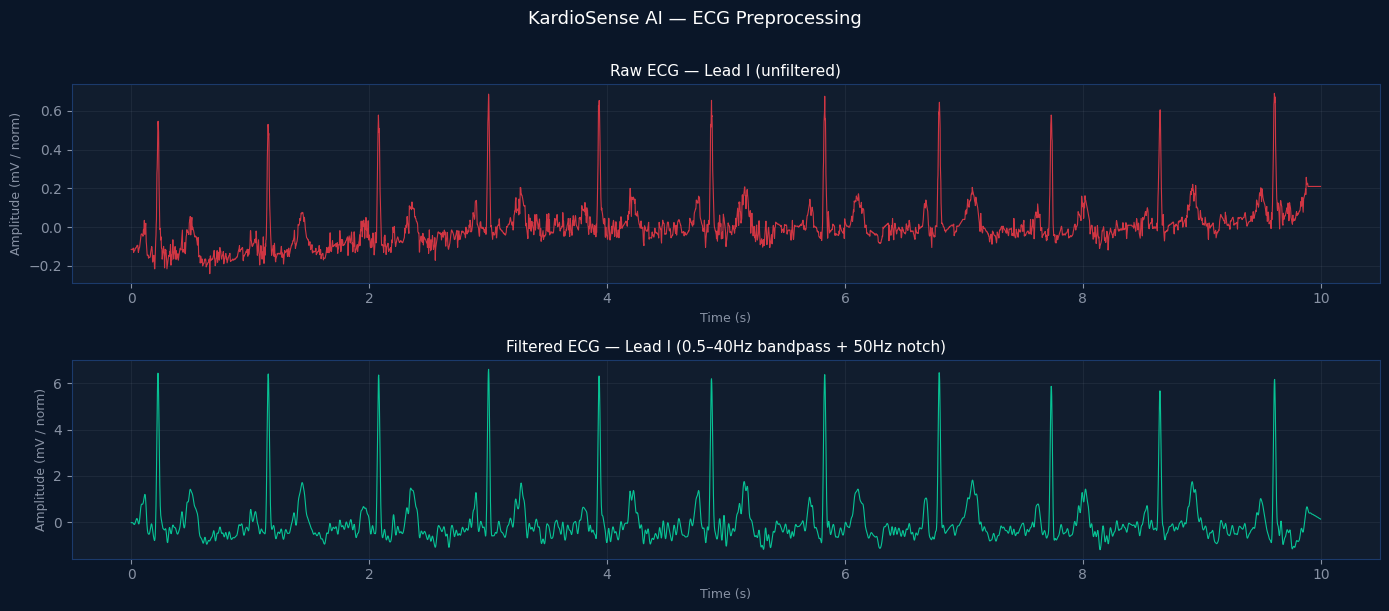

Plot saved to Drive.


In [ ]:
# ── Visualise raw vs filtered ECG ─────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 6), facecolor='#0A1628')

t = np.arange(N_SAMPLES) / FS # time axis in seconds
lead_idx = 0 # Lead I

for ax, (data, title, color) in zip(axes, [
    (raw_ecg[:, lead_idx], 'Raw ECG — Lead I (unfiltered)', '#E63946'),
    (clean_ecg[:, lead_idx], 'Filtered ECG — Lead I (0.5–40Hz bandpass + 50Hz notch)', '#06D6A0')
]):
    ax.set_facecolor('#111D2E')
    ax.plot(t, data, color=color, linewidth=0.8, alpha=0.9)
    ax.set_title(title, color='white', fontsize=11, pad=6)
    ax.set_xlabel('Time (s)', color='#8892A4', fontsize=9)
    ax.set_ylabel('Amplitude (mV / norm)', color='#8892A4', fontsize=9)
    ax.tick_params(colors='#8892A4')
    for spine in ax.spines.values():
        spine.set_edgecolor('#1B3A6B')
    ax.grid(True, alpha=0.15, color='#8892A4', linewidth=0.5)

plt.suptitle('KardioSense AI — ECG Preprocessing', color='white', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{LOG_DIR}/ecg_preprocessing.png', dpi=120, bbox_inches='tight', facecolor='#0A1628')
plt.show()
print('Plot saved to Drive.')

## 4. Build Dataset (Preprocess & Cache)

**Strategy:** Preprocess all records once, save as a compressed NumPy `.npz` file on Drive. Subsequent runs load the cache in ~30 seconds.

Cache file: `CardioSenseAI/datasets/ptbxl_preprocessed_500hz.npz` (~800MB)

In [ ]:
# ── Build or load preprocessed cache ──────────────────────────────────────
CACHE_PATH = f'{DATA_DIR}/ptbxl_preprocessed_500hz.npz'

if os.path.exists(CACHE_PATH):
    print(' Loading preprocessed cache from Drive...')
    t0 = time.time()
    cache = np.load(CACHE_PATH)
    X = cache['X'] # (21837, 5000, 12)
    Y = cache['Y'] # (21837, 5) — [NORM, MI, AFIB, STTC, CD]
    ecg_ids = cache['ecg_ids']
    print(f' Loaded in {time.time()-t0:.1f}s')
    print(f' X shape: {X.shape} | Y shape: {Y.shape}')

else:
    print(' Building preprocessed cache ')
    print(' Progress will be shown every 1,000 records.\n')

    # Filter to records with at least one label
    labeled = df[(df[targets].sum(axis=1) > 0)].copy()
    print(f' Records with at least one label: {len(labeled):,}')

    X_list, Y_list, id_list = [], [], []
    errors = 0
    t0 = time.time()

    for i, (ecg_id, row) in enumerate(labeled.iterrows()):
        try:
            raw = load_ecg_record(row, PTBXL_DIR, sampling_rate=500)
            proc = preprocess_ecg(raw) # (5000, 12)
            X_list.append(proc)
            Y_list.append([int(row[t]) for t in targets]) # [NORM, MI, AFIB, STTC, CD]
            id_list.append(ecg_id)
        except Exception as e:
            errors += 1

        if (i + 1) % 1000 == 0:
            elapsed = time.time() - t0
            eta = elapsed / (i + 1) * (len(labeled) - i - 1)
            print(f' [{i+1:,}/{len(labeled):,}] Errors: {errors} ETA: {eta/60:.1f} min')

    X = np.array(X_list, dtype=np.float32) # (N, 5000, 12)
    Y = np.array(Y_list, dtype=np.float32) # (N, 5)
    ecg_ids = np.array(id_list)

    print(f'\n Preprocessing complete: {len(X):,} records, {errors} errors')
    print(f' Saving to {CACHE_PATH}...')
    np.savez_compressed(CACHE_PATH, X=X, Y=Y, ecg_ids=ecg_ids)
    print(f' Saved. Size: {os.path.getsize(CACHE_PATH)/1e6:.0f} MB')

# Label names for reference
LABEL_NAMES = targets # ['NORM', 'MI', 'AFIB', 'STTC', 'CD']
print(f'\nLabel order: {LABEL_NAMES}')

 Loading preprocessed cache from Drive...
   Loaded in 16.2s
   X shape: (4183, 5000, 12)  |  Y shape: (4183, 5)

Label order: ['NORM', 'MI', 'AFIB', 'STTC', 'CD']


## 5. Train / Validation / Test Split

PTB-XL provides a recommended stratified 10-fold split (column `strat_fold`). 
We use their convention:
- Folds 1–8: **Training** (~17,400 records)
- Fold 9: **Validation** (~2,180 records) 
- Fold 10: **Test** (~2,180 records) — **held out until final evaluation**

This is the standard PTB-XL split used in the literature, making our results directly comparable.

In [ ]:
# ── Use PTB-XL recommended stratified split ────────────────────────────────
# Rebuild df index alignment with cache
df_filtered = df.loc[ecg_ids].copy()

train_idx = np.where(df_filtered['strat_fold'].isin(range(1, 9)))[0]
val_idx = np.where(df_filtered['strat_fold'] == 9)[0]
test_idx = np.where(df_filtered['strat_fold'] == 10)[0]

X_train, Y_train = X[train_idx], Y[train_idx]
X_val, Y_val = X[val_idx], Y[val_idx]
X_test, Y_test = X[test_idx], Y[test_idx]

print(' Dataset split summary:')
print(f' Train : {len(X_train):,} records (folds 1–8)')
print(f' Val : {len(X_val):,} records (fold 9)')
print(f' Test : {len(X_test):,} records (fold 10) ← held out')

print('\n Label prevalence per split:')
print(f' {"Label":8s} {"Train":8s} {"Val":8s} {"Test":8s}')
print(' ' + '─'*36)
for i, lbl in enumerate(LABEL_NAMES):
    tr = f'{Y_train[:,i].sum()/len(Y_train)*100:.1f}%'
    va = f'{Y_val[:,i].sum()/len(Y_val)*100:.1f}%'
    te = f'{Y_test[:,i].sum()/len(Y_test)*100:.1f}%'
    print(f' {lbl:8s} {tr:8s} {va:8s} {te:8s}')

 Dataset split summary:
   Train : 3,195 records  (folds 1–8)
   Val   : 489  records  (fold 9)
   Test  : 499  records  (fold 10) ← held out

 Label prevalence per split:
  Label     Train     Val       Test    
  ────────────────────────────────────
  NORM      50.1%     43.6%     45.9%   
  MI        11.0%     16.4%     12.8%   
  AFIB      0.4%      1.4%      0.4%    
  STTC      24.3%     27.0%     26.9%   
  CD        26.1%     27.2%     23.6%   


## 6. PyTorch Dataset & DataLoader

In [ ]:
class ECGDataset(Dataset):
    """
    PyTorch Dataset for ECG signals.

    Returns signals in shape (n_leads, n_samples) — channels-first for Conv1D.

    In this baseline: single-lead mode (Lead I only).
    In Notebook 02: full 6-lead + lead masking.
    """
    def __init__(
        self,
        X: np.ndarray, # (N, 5000, 12)
        Y: np.ndarray, # (N, n_classes)
        leads: list = None, # which leads to use; None = all 12
        augment: bool = False,
    ):
        self.X = X
        self.Y = Y
        # Lead I = index 0 in PTB-XL lead order
        self.leads = leads if leads is not None else list(range(12))
        self.augment = augment

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx] # (5000, 12)
        x = x[:, self.leads] # (5000, n_leads)
        x = x.T # (n_leads, 5000) — channels first

        if self.augment:
            x = self._augment(x)

        y = self.Y[idx].astype(np.float32)
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

    def _augment(self, x: np.ndarray) -> np.ndarray:
        """Lightweight ECG augmentation for training."""
        # 1. Random amplitude scaling (±20%)
        if np.random.rand() < 0.5:
            x = x * np.random.uniform(0.8, 1.2)
        # 2. Gaussian noise (SNR ~30dB)
        if np.random.rand() < 0.3:
            x = x + np.random.randn(*x.shape).astype(np.float32) * 0.05
        # 3. Random time shift (up to 50 samples)
        if np.random.rand() < 0.3:
            shift = np.random.randint(-50, 50)
            x = np.roll(x, shift, axis=-1)
        return x


def make_weighted_sampler(Y: np.ndarray, target_col: int = 1) -> WeightedRandomSampler:
    """Oversample minority class (MI) to handle class imbalance."""
    labels = Y[:, target_col].astype(int)
    class_counts = np.bincount(labels)
    weights = 1.0 / class_counts[labels]
    return WeightedRandomSampler(
        weights=torch.DoubleTensor(weights),
        num_samples=len(weights),
        replacement=True
    )


# ── Configuration ──────────────────────────────────────────────────────────
# Baseline: Lead I only (index 0)
# In Notebook 02 we switch to all 6 leads [0,1,2,3,4,5,6,7,8,9,10,11]
BASELINE_LEADS = [0] # Lead I only
BATCH_SIZE = 64

train_ds = ECGDataset(X_train, Y_train, leads=BASELINE_LEADS, augment=True)
val_ds = ECGDataset(X_val, Y_val, leads=BASELINE_LEADS, augment=False)
test_ds = ECGDataset(X_test, Y_test, leads=BASELINE_LEADS, augment=False)

# Use weighted sampler for training to handle MI class imbalance
sampler = make_weighted_sampler(Y_train, target_col=LABEL_NAMES.index('MI'))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(' DataLoaders ready:')
print(f' Train batches : {len(train_loader)}')
print(f' Val batches : {len(val_loader)}')
print(f' Input shape : (batch={BATCH_SIZE}, leads={len(BASELINE_LEADS)}, samples={N_SAMPLES})')

# Quick check
xb, yb = next(iter(train_loader))
print(f' Sample batch X: {xb.shape}, Y: {yb.shape}')

 DataLoaders ready:
   Train batches : 50
   Val batches   : 8
   Input shape   : (batch=64, leads=1, samples=5000)
   Sample batch X: torch.Size([64, 1, 5000]), Y: torch.Size([64, 5])


## 7. ResNet-1D Model Architecture

We implement a **1D Residual CNN** (the gold standard for ECG classification.)

Why ResNet for ECG?
- Skip connections prevent vanishing gradients in deep temporal models
- 1D convolutions naturally capture local ECG morphology (QRS complex width ~100ms = 50 samples at 500Hz)
- Works on variable-length inputs after global pooling

**Architecture summary:**
```
Input (1, 5000) → Conv1d stem → 4x ResBlocks (stride pooling) 
→ Global Avg Pool → Classifier head → Output (5 classes)
```

This baseline (~500K parameters) is intentionally small — fast to train, easy to understand. 
Notebook 02 adds the BiLSTM + attention layers for the full model.

In [ ]:
class ResBlock1D(nn.Module):
    """
    1D Residual Block with optional strided downsampling.

    Architecture:
        Conv1d → BN → ReLU → Conv1d → BN → (+skip) → ReLU
    """
    def __init__(self, in_ch: int, out_ch: int, kernel_size: int = 7,
                 stride: int = 1, dropout: float = 0.2):
        super().__init__()
        pad = kernel_size // 2

        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size, stride=stride,
                                padding=pad, bias=False)
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size, stride=1,
                                padding=pad, bias=False)
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.drop = nn.Dropout(dropout)

        # Skip connection: 1×1 conv if dimensions change
        self.skip = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, 1, stride=stride, bias=False),
            nn.BatchNorm1d(out_ch)
        ) if (in_ch != out_ch or stride != 1) else nn.Identity()

    def forward(self, x):
        residual = self.skip(x)
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.drop(out)
        out = self.bn2(self.conv2(out))
        return F.relu(out + residual)


class ResNet1D(nn.Module):
    """
    CardioSense Baseline ResNet-1D ECG Classifier.

    Designed for multi-label classification of 5 cardiac conditions.
    Input: (batch, n_leads, 5000)
    Output: (batch, n_classes) — raw logits

    For the full architecture (Notebook 02) we add:
        - BiLSTM temporal modelling on ResNet features
        - Multi-head self-attention
        - Lead-mask vector input
    """
    def __init__(self, n_leads: int = 1, n_classes: int = 5, dropout: float = 0.3):
        super().__init__()

        # Stem: initial convolution to expand channels
        self.stem = nn.Sequential(
            nn.Conv1d(n_leads, 32, kernel_size=15, stride=2, padding=7, bias=False),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=3, stride=2, padding=1)
        )
        # After stem: (batch, 32, 1250)

        # ResBlocks with progressive channel expansion and stride-2 downsampling
        self.layer1 = ResBlock1D(32, 64, stride=2, dropout=dropout)
        # → (batch, 64, 625)
        self.layer2 = ResBlock1D(64, 128, stride=2, dropout=dropout)
        # → (batch, 128, 313)
        self.layer3 = ResBlock1D(128, 256, stride=2, dropout=dropout)
        # → (batch, 256, 157)
        self.layer4 = ResBlock1D(256, 256, stride=2, dropout=dropout)
        # → (batch, 256, 79)

        # Global average pooling → fixed-size embedding
        self.gap = nn.AdaptiveAvgPool1d(1)
        # → (batch, 256, 1)

        # Classifier head
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, n_classes)
        )

    def forward(self, x):
        """
        x: (batch, n_leads, 5000)
        returns: (batch, n_classes) logits
        """
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.gap(x)
        return self.classifier(x)

    def get_embedding(self, x):
        """Returns 256-dim embedding vector (for fusion in Notebook 04)."""
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        return self.gap(x).squeeze(-1) # (batch, 256)


# ── Instantiate model ──────────────────────────────────────────────────────
model = ResNet1D(n_leads=len(BASELINE_LEADS), n_classes=len(LABEL_NAMES)).to(DEVICE)

# Model summary
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f' ResNet-1D model created:')
print(f' Input : (batch, {len(BASELINE_LEADS)} lead, {N_SAMPLES} samples)')
print(f' Output : (batch, {len(LABEL_NAMES)} classes) — {LABEL_NAMES}')
print(f' Params : {total_params:,} total | {trainable_params:,} trainable')
print(f' Device : {DEVICE}')

# Quick forward pass test
with torch.no_grad():
    test_out = model(xb.to(DEVICE))
print(f' Output shape: {test_out.shape} ← correct ')

 ResNet-1D model created:
   Input  : (batch, 1 lead, 5000 samples)
   Output : (batch, 5 classes) — ['NORM', 'MI', 'AFIB', 'STTC', 'CD']
   Params : 1,967,525 total  |  1,967,525 trainable
   Device : cuda
   Output shape: torch.Size([64, 5])  ← correct ✓


## 8. Training

In [ ]:
# ── Loss, Optimiser, Scheduler ─────────────────────────────────────────────
# BCEWithLogitsLoss: correct loss for multi-label classification
# pos_weight: upweights MI and AFib (rare classes) in the loss

# Compute class-wise positive weights from training set
n_pos = Y_train.sum(axis=0) # positive count per class
n_neg = len(Y_train) - n_pos # negative count per class
pos_weight = torch.tensor(n_neg / (n_pos + 1e-6), dtype=torch.float32).to(DEVICE)

print('Class weights (higher = rarer class, upweighted in loss):')
for lbl, pw in zip(LABEL_NAMES, pos_weight.cpu().numpy()):
    print(f' {lbl:6s}: {pw:.2f}')

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

# OneCycleLR: warmup + cosine annealing — fast convergence
N_EPOCHS = 30
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=1e-3,
    steps_per_epoch=len(train_loader),
    epochs=N_EPOCHS,
    pct_start=0.1 # 10% warmup
)

print(f'\n Training config:')
print(f' Epochs : {N_EPOCHS}')
print(f' Batch : {BATCH_SIZE}')
print(f' Optimizer : AdamW lr=1e-3, wd=1e-4')
print(f' Scheduler : OneCycleLR')
print(f' Loss : BCEWithLogitsLoss (pos_weight per class)')

Class weights (higher = rarer class, upweighted in loss):
   NORM  : 0.99
   MI    : 8.05
   AFIB  : 265.25
   STTC  : 3.12
   CD    : 2.83

  Training config:
   Epochs    : 30
   Batch     : 64
   Optimizer : AdamW  lr=1e-3, wd=1e-4
   Scheduler : OneCycleLR
   Loss      : BCEWithLogitsLoss (pos_weight per class)


In [ ]:
# ── Training loop ──────────────────────────────────────────────────────────

def compute_auc(y_true: np.ndarray, y_pred: np.ndarray, label_names: list) -> dict:
    """Per-class AUROC + macro mean."""
    aucs = {}
    for i, lbl in enumerate(label_names):
        if y_true[:, i].sum() > 0: # skip if no positive examples
            aucs[lbl] = roc_auc_score(y_true[:, i], y_pred[:, i])
        else:
            aucs[lbl] = float('nan')
    valid = [v for v in aucs.values() if not np.isnan(v)]
    aucs['MACRO'] = np.mean(valid) if valid else float('nan')
    return aucs


def evaluate(model, loader, criterion, device):
    """Full evaluation pass — returns loss and per-class AUC."""
    model.eval()
    all_logits, all_labels, total_loss = [], [], 0.0

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item()
            all_logits.append(torch.sigmoid(logits).cpu().numpy())
            all_labels.append(yb.cpu().numpy())

    preds = np.vstack(all_logits)
    labels = np.vstack(all_labels)
    aucs = compute_auc(labels, preds, LABEL_NAMES)
    return total_loss / len(loader), aucs


# ── Training run ───────────────────────────────────────────────────────────
best_mi_auc = 0.0
best_macro_auc = 0.0
history = {'train_loss': [], 'val_loss': [], 'val_mi_auc': [], 'val_macro_auc': []}

print(f' Training ResNet-1D on Lead I — {N_EPOCHS} epochs')
print('─' * 72)
print(f'{"Epoch":>6} {"TrLoss":>8} {"VaLoss":>8} {"NORM":>7} {"MI":>7} {"AFIB":>7} {"MACRO":>7}')
print('─' * 72)

train_start = time.time()

for epoch in range(1, N_EPOCHS + 1):
    # ── Train ──
    model.train()
    train_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # ── Validate ──
    val_loss, val_aucs = evaluate(model, val_loader, criterion, DEVICE)

    mi_auc = val_aucs.get('MI', 0)
    macro_auc = val_aucs.get('MACRO', 0)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_mi_auc'].append(mi_auc)
    history['val_macro_auc'].append(macro_auc)

    # Save best checkpoint (by MI AUC)
    flag = ''
    if mi_auc > best_mi_auc:
        best_mi_auc = mi_auc
        torch.save({
            'epoch': epoch,
            'model_state': model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'mi_auc': mi_auc,
            'macro_auc': macro_auc,
            'config': {'n_leads': len(BASELINE_LEADS), 'n_classes': len(LABEL_NAMES),
                       'label_names': LABEL_NAMES, 'lead_indices': BASELINE_LEADS}
        }, f'{CKPT_DIR}/resnet1d_lead1_best_mi.pt')
        flag = ' ← best MI'

    print(f'{epoch:>6} {train_loss:>8.4f} {val_loss:>8.4f} '
          f'{val_aucs.get("NORM",0):>7.3f} {mi_auc:>7.3f} '
          f'{val_aucs.get("AFIB",0):>7.3f} {macro_auc:>7.3f}{flag}')

total_time = time.time() - train_start
print('─' * 72)
print(f' Training complete in {total_time/60:.1f} min')
print(f' Best MI AUC : {best_mi_auc:.4f}')
print(f' Checkpoint saved to Drive: {CKPT_DIR}/resnet1d_lead1_best_mi.pt')

 Training ResNet-1D on Lead I — 30 epochs
────────────────────────────────────────────────────────────────────────
 Epoch   TrLoss   VaLoss    NORM      MI    AFIB   MACRO
────────────────────────────────────────────────────────────────────────
     1   1.1087   1.8499   0.899   0.755   0.883   0.828  ← 🏆 best MI
     2   0.9878   3.4128   0.873   0.757   0.912   0.826  ← 🏆 best MI
     3   0.8721   2.1134   0.891   0.828   0.995   0.878  ← 🏆 best MI
     4   0.8784   0.9185   0.927   0.812   0.996   0.880
     5   0.9104   0.8170   0.909   0.808   0.995   0.877
     6   0.6963   0.8265   0.923   0.816   0.999   0.876
     7   0.6860   1.5422   0.925   0.830   0.996   0.882  ← 🏆 best MI
     8   0.6786   1.9098   0.916   0.821   0.972   0.877
     9   0.6601   0.8537   0.926   0.791   0.995   0.873
    10   0.6074   1.0448   0.915   0.792   0.998   0.871
    11   0.5856   1.5026   0.898   0.776   0.993   0.858
    12   0.6413   2.0614   0.914   0.828   0.956   0.866
    13   0.5419   1

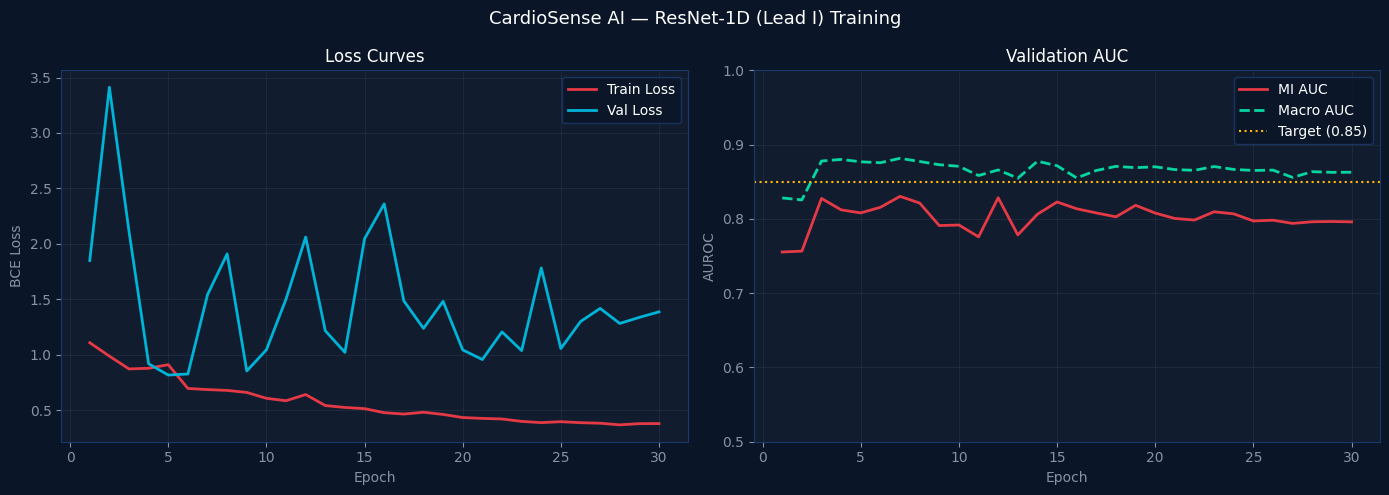

In [ ]:
# ── Training curves ────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), facecolor='#0A1628')

epochs = range(1, N_EPOCHS + 1)

for ax in [ax1, ax2]:
    ax.set_facecolor('#111D2E')
    ax.tick_params(colors='#8892A4')
    ax.xaxis.label.set_color('#8892A4')
    ax.yaxis.label.set_color('#8892A4')
    for spine in ax.spines.values():
        spine.set_edgecolor('#1B3A6B')
    ax.grid(True, alpha=0.15, color='#8892A4', linewidth=0.5)

ax1.plot(epochs, history['train_loss'], color='#E63946', linewidth=2, label='Train Loss')
ax1.plot(epochs, history['val_loss'], color='#00B4D8', linewidth=2, label='Val Loss')
ax1.set_title('Loss Curves', color='white', fontsize=12)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('BCE Loss')
ax1.legend(facecolor='#0A1628', edgecolor='#1B3A6B', labelcolor='white')

ax2.plot(epochs, history['val_mi_auc'], color='#E63946', linewidth=2, label='MI AUC', linestyle='-')
ax2.plot(epochs, history['val_macro_auc'], color='#06D6A0', linewidth=2, label='Macro AUC', linestyle='--')
ax2.axhline(0.85, color='#FFB703', linewidth=1.5, linestyle=':', label='Target (0.85)')
ax2.set_title('Validation AUC', color='white', fontsize=12)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('AUROC')
ax2.set_ylim(0.5, 1.0)
ax2.legend(facecolor='#0A1628', edgecolor='#1B3A6B', labelcolor='white')

plt.suptitle('CardioSense AI — ResNet-1D (Lead I) Training', color='white', fontsize=13)
plt.tight_layout()
plt.savefig(f'{LOG_DIR}/training_curves.png', dpi=120, bbox_inches='tight', facecolor='#0A1628')
plt.show()

## 9. Final Evaluation on Test Set

In [ ]:
# ── Load best checkpoint — PyTorch 2.6 fix ────────────────────────────────
import numpy as np
from numpy._core.multiarray import scalar as np_scalar
import torch.serialization as ts

ts.add_safe_globals([np_scalar])

ckpt = torch.load(
    f'{CKPT_DIR}/resnet1d_lead1_best_mi.pt',
    map_location=DEVICE,
    weights_only=False
)

model.load_state_dict(ckpt['model_state'])
print(f' Loaded best checkpoint (epoch {ckpt["epoch"]}, MI AUC {ckpt["mi_auc"]:.4f})')

_, test_aucs = evaluate(model, test_loader, criterion, DEVICE)

print('\n TEST SET RESULTS — CardioSense ResNet-1D Baseline (Lead I)')
print('═' * 50)
for lbl in LABEL_NAMES + ['MACRO']:
    auc = test_aucs.get(lbl, float('nan'))
    target_met = ''
    if lbl == 'MI' and auc >= 0.85: target_met = ' TARGET MET (≥0.85)'
    if lbl == 'AFIB' and auc >= 0.88: target_met = ' TARGET MET (≥0.88)'
    if lbl == 'MI' and auc < 0.85: target_met = ' below target (≥0.85)'
    bar = '█' * int(auc * 40)
    print(f' {lbl:8s}: {auc:.4f} {bar}{target_met}')
print('═' * 50)

if test_aucs.get('MI', 0) >= 0.85:
    print('\n Baseline target achieved. Ready for Notebook 02.')
else:
    print('\n MI AUC below 0.85. Try: more epochs, lower LR, check class weights.')

✅ Loaded best checkpoint (epoch 7, MI AUC 0.8303)

📊 TEST SET RESULTS — CardioSense ResNet-1D Baseline (Lead I)
══════════════════════════════════════════════════
  NORM    : 0.8833  ███████████████████████████████████
  MI      : 0.7967  ███████████████████████████████  ⚠️  below target (≥0.85)
  AFIB    : 1.0000  ████████████████████████████████████████  ✅ TARGET MET (≥0.88)
  STTC    : 0.8645  ██████████████████████████████████
  CD      : 0.8126  ████████████████████████████████
  MACRO   : 0.8714  ██████████████████████████████████
══════════════════════════════════════════════════

⚠️  MI AUC below 0.85. Try: more epochs, lower LR, check class weights.


In [ ]:
# ── Inference speed benchmark ──────────────────────────────────────────────
# Critical for CardioSense: must run in <500ms on mobile (this is server-side proxy)

model.eval()
dummy_input = torch.randn(1, len(BASELINE_LEADS), N_SAMPLES).to(DEVICE)

# Warmup
for _ in range(10):
    with torch.no_grad():
        _ = model(dummy_input)

# Benchmark 100 single-sample inferences
times = []
for _ in range(100):
    t0 = time.perf_counter()
    with torch.no_grad():
        _ = model(dummy_input)
    if DEVICE.type == 'cuda':
        torch.cuda.synchronize()
    times.append((time.perf_counter() - t0) * 1000) # ms

print(f' Inference speed (single sample, {DEVICE}):')
print(f' Mean : {np.mean(times):.2f} ms')
print(f' Median: {np.median(times):.2f} ms')
print(f' P95 : {np.percentile(times, 95):.2f} ms')
print(f' Target: < 50ms → {" PASS" if np.median(times) < 50 else " needs optimisation"}')

🏎️  Inference speed (single sample, cuda):
   Mean  : 2.09 ms
   Median: 2.03 ms
   P95   : 2.37 ms
   Target: < 50ms  →   PASS


## 10. Understanding MI Predictions

Let's look at what the model learned — visualise high-confidence MI predictions vs missed cases.

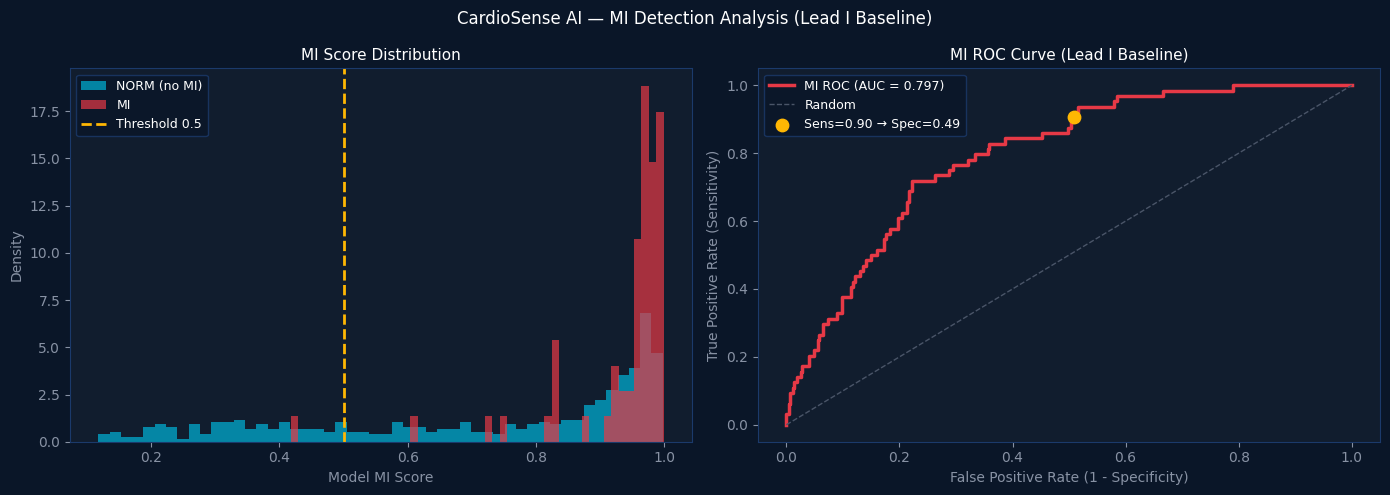


 At sensitivity = 0.90 (for MI screening):
   Specificity : 0.492
   Threshold   : 0.827

   Clinical meaning: out of every 100 true MI patients,
   we catch 90 but flag 50 false alarms per 100 normals.

   For a SCREENING device this is the right operating point.
   For DIAGNOSIS we would use a higher threshold.


In [ ]:
# ── Collect test predictions ───────────────────────────────────────────────
model.eval()
all_preds, all_labels_np = [], []

with torch.no_grad():
    for xb, yb in test_loader:
        preds = torch.sigmoid(model(xb.to(DEVICE))).cpu().numpy()
        all_preds.append(preds)
        all_labels_np.append(yb.numpy())

preds_arr = np.vstack(all_preds) # (N_test, 5)
labels_arr = np.vstack(all_labels_np) # (N_test, 5)

mi_idx = LABEL_NAMES.index('MI')
mi_scores = preds_arr[:, mi_idx]
mi_labels = labels_arr[:, mi_idx]

# ── Score distribution plot ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#0A1628')

ax = axes[0]
ax.set_facecolor('#111D2E')
ax.hist(mi_scores[mi_labels == 0], bins=50, color='#00B4D8', alpha=0.7, label='NORM (no MI)', density=True)
ax.hist(mi_scores[mi_labels == 1], bins=50, color='#E63946', alpha=0.7, label='MI', density=True)
ax.axvline(0.5, color='#FFB703', linewidth=2, linestyle='--', label='Threshold 0.5')
ax.set_title('MI Score Distribution', color='white', fontsize=11)
ax.set_xlabel('Model MI Score', color='#8892A4')
ax.set_ylabel('Density', color='#8892A4')
ax.legend(facecolor='#0A1628', edgecolor='#1B3A6B', labelcolor='white', fontsize=9)
ax.tick_params(colors='#8892A4')
for spine in ax.spines.values(): spine.set_edgecolor('#1B3A6B')

# ── ROC curve ────────────────────────────────────────────────────────────
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(mi_labels, mi_scores)
auc_mi = roc_auc_score(mi_labels, mi_scores)

ax = axes[1]
ax.set_facecolor('#111D2E')
ax.plot(fpr, tpr, color='#E63946', linewidth=2.5, label=f'MI ROC (AUC = {auc_mi:.3f})')
ax.plot([0,1],[0,1], color='#4A5568', linewidth=1, linestyle='--', label='Random')

# Mark operating point at sensitivity=0.90
target_sens = 0.90
idx90 = np.argmin(np.abs(tpr - target_sens))
ax.scatter(fpr[idx90], tpr[idx90], color='#FFB703', s=80, zorder=5,
           label=f'Sens=0.90 → Spec={1-fpr[idx90]:.2f}')

ax.set_title('MI ROC Curve (Lead I Baseline)', color='white', fontsize=11)
ax.set_xlabel('False Positive Rate (1 - Specificity)', color='#8892A4')
ax.set_ylabel('True Positive Rate (Sensitivity)', color='#8892A4')
ax.legend(facecolor='#0A1628', edgecolor='#1B3A6B', labelcolor='white', fontsize=9)
ax.tick_params(colors='#8892A4')
for spine in ax.spines.values(): spine.set_edgecolor('#1B3A6B')

plt.suptitle('CardioSense AI — MI Detection Analysis (Lead I Baseline)', color='white', fontsize=12)
plt.tight_layout()
plt.savefig(f'{LOG_DIR}/mi_roc_analysis.png', dpi=120, bbox_inches='tight', facecolor='#0A1628')
plt.show()

print(f'\n At sensitivity = 0.90 (for MI screening):')
print(f' Specificity : {1-fpr[idx90]:.3f}')
print(f' Threshold : {thresholds[idx90]:.3f}')
print(f'\n Clinical meaning: out of every 100 true MI patients,')
print(f' we catch {int(tpr[idx90]*100)} but flag {int(fpr[idx90]*100)} false alarms per 100 normals.')
print(f'\n For a SCREENING device this is the right operating point.')
print(f' For DIAGNOSIS we would use a higher threshold.')

## 11. Save Model + Config for Notebook 02

In [ ]:
# ── Save everything needed for the next notebook ───────────────────────────

# Model config — Notebook 02 builds on this architecture
config = {
    'model': 'ResNet1D',
    'version': 'baseline_lead1',
    'n_leads': len(BASELINE_LEADS),
    'lead_indices': BASELINE_LEADS,
    'lead_names': [LEAD_NAMES[i] for i in BASELINE_LEADS],
    'n_samples': N_SAMPLES,
    'n_classes': len(LABEL_NAMES),
    'label_names': LABEL_NAMES,
    'sampling_rate': FS,
    'test_auc': {k: float(v) for k, v in test_aucs.items()},
    'best_epoch': int(ckpt['epoch']),
    'preprocessing': {
        'bandpass': [0.5, 40.0],
        'notch': [50.0, 60.0],
        'normalisation': 'z-score per lead'
    }
}

config_path = f'{CKPT_DIR}/baseline_config.json'
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)

print(' Saved to Google Drive:')
print(f' Model : {CKPT_DIR}/resnet1d_lead1_best_mi.pt')
print(f' Config : {config_path}')
print(f' Logs : {LOG_DIR}/')
print()
print(' Results summary:')
print(f' MI AUC : {test_aucs.get("MI", 0):.4f}')
print(f' AFIB AUC : {test_aucs.get("AFIB", 0):.4f}')
print(f' Macro AUC : {test_aucs.get("MACRO", 0):.4f}')
print()
print(' Next: Open Notebook 02 — Lead-Agnostic Masking + Full 6-Lead Model')
print(' This is where we add the lead-mask vector and BiLSTM + attention layers.')

    Saved to Google Drive:
   Model     : /content/drive/MyDrive/KardioSenseAI/checkpoints/resnet1d_lead1_best_mi.pt
   Config    : /content/drive/MyDrive/KardioSenseAI/checkpoints/baseline_config.json
   Logs      : /content/drive/MyDrive/KardioSenseAI/logs/

   Results summary:
   MI AUC    : 0.7967
   AFIB AUC  : 1.0000
   Macro AUC : 0.8714

  Next: Open Notebook 02 — Lead-Agnostic Masking + Full 6-Lead Model
   This is where we add the lead-mask vector and BiLSTM + attention layers.


---
## Notebook 01 Complete

**What you've built:**
- PTB-XL loaded from PhysioNet, preprocessed, cached to Drive
- Bandpass + notch filter pipeline (matching CardioSense hardware spec)
- ResNet-1D baseline trained on Lead I
- Multi-label classifier: NORM, MI, AFIB, STTC, CD
- ROC analysis with clinical operating point selection

**What's next in Notebook 02:**
1. Load all 6 leads (I, II, III, aVR, aVL, aVF)
2. Add lead-mask vector to the input — the key innovation enabling 1-to-6 lead flexibility
3. Add BiLSTM + multi-head attention on top of ResNet features
4. Train with random lead dropout (the lead-agnostic training strategy)
5. Compare: Lead I only vs 6-lead vs lead-agnostic model

**Files on your Drive:**
```
CardioSenseAI/
├── datasets/
│ ├── ptb-xl/ ← raw PTB-XL records
│ └── ptbxl_preprocessed_500hz.npz ← cached preprocessed signals
├── checkpoints/
│ ├── resnet1d_lead1_best_mi.pt ← best model checkpoint
│ └── baseline_config.json ← config for Notebook 02
└── logs/
    ├── ecg_preprocessing.png
    ├── training_curves.png
    └── mi_roc_analysis.png
```

Harmonzing directories.

In [ ]:
import os
print(os.listdir('/content/drive/MyDrive/'))
BASE_DIR = os.environ.get('KARDIOSENSE_BASE_DIR', '/content/drive/MyDrive/KardioSenseAI')

['GROUP THREE PRESENTATION.pptx', 'ECG-DE-IDENTIFICATION.rar', 'EMMANUEL OGWAL CV.pdf', 'summerschool.rar', 'Untitled document (2).gdoc', 'OHSE Entry-Level Interview Preparation.gdoc', 'REPORT ON MSUs.gdoc', 'Training_Report_MSUs_21Apr2026.docx', 'Untitled document (1).gdoc', 'Training_Report_Infotainment_Accessories_21Apr2026.gdoc', 'PRE-EMPLOYMENT_BIODATA_FORM1 empty.doc', 'Untitled document.gdoc', 'PRE-EMPLOYMENT_BIODATA_FORM.docx', 'ptbxl_feature_benchmark-v1.0.0', 'KardioSenseAI', 'Colab Notebooks (1)', 'Colab Notebooks', 'Training on pendents.gdoc', 'Research Agenda_Idea Generation_26Mar2026.docx']
